# RAG-техники и метрики

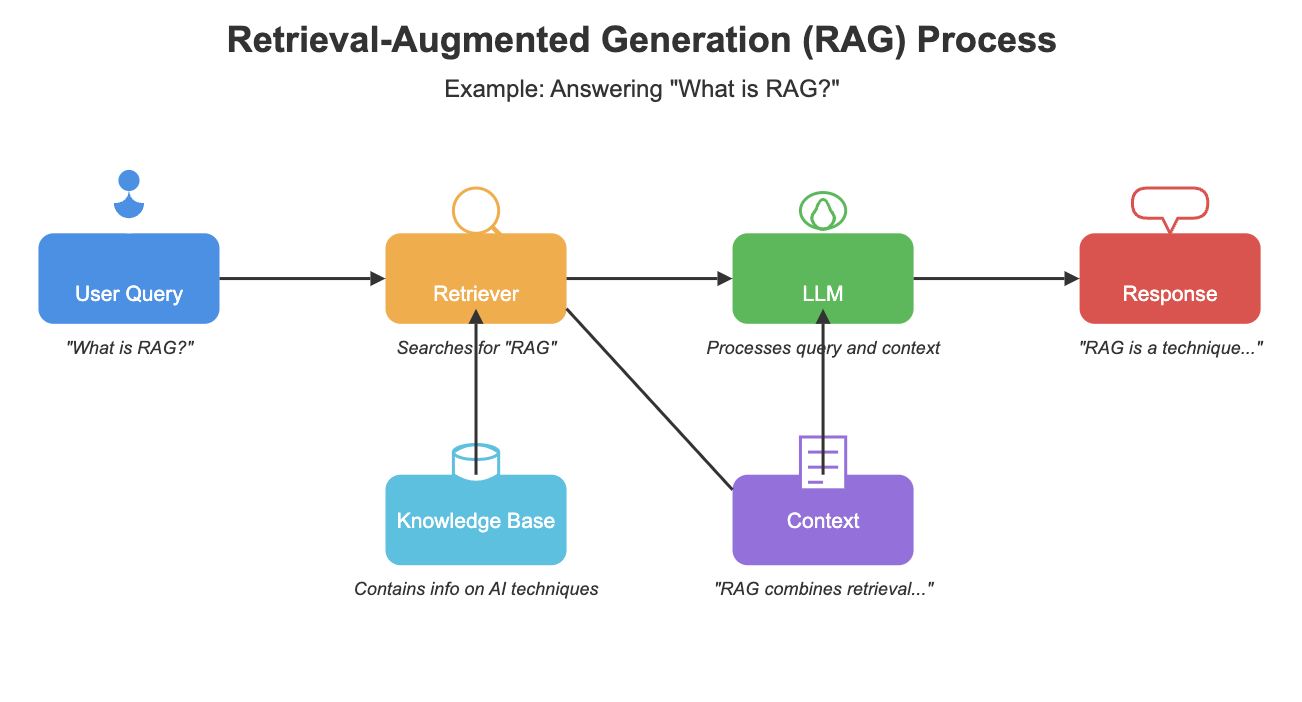

# Среда выполнения - Сменить среду выполнения - GPU (T4)

# Практика 1. Retrieval Augmented Generation: чат-бот по банковским вкладам

Сегодня мы построим умного чат-бота, который отвечает на вопросы про вклады в российских банках.
Он будет искать ответы в базе знаний, а не выдумывать их. Эта технология называется RAG.

Что будет на уроке:
- Что такое RAG и зачем он нужен
- Как устроена база знаний и векторный поиск
- Как измерить качество поиска (MRR, Hit Rate)
- Как улучшить качество шаг за шагом
- Телеграм-бот с поиском по вкладам
- Метрики: ML, продуктовые, бизнесовые

По ходу урока вы будете дописывать код и улучшать бота.

In [1]:
!pip install telebot requests numpy pandas scikit-learn sentence-transformers transformers torch accelerate -q

import telebot
import threading
import time
import json
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# === Функция для остановки бота ===
# запускается в начале каждого задания
def stop_bot():
    try:
        bot.stop_polling()
        time.sleep(1)
    except:
        pass

# создать в botfather
TOKEN = ""


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 12.1 MB/s eta 0:00:00


---
# Часть 1. Что такое RAG и зачем он нужен

## Проблема: языковые модели врут

Языковая модель (LLM) - это программа, которая умеет генерировать текст.
Например, ChatGPT, Gemini, Claude. Они знают много, но у них есть проблема:
они могут уверенно врать. Это называется "галлюцинация".

Пример. Ты спрашиваешь модель: "Какая ставка по вкладу в Сбербанке?"
Модель отвечает: "12% годовых на 6 месяцев."
Звучит убедительно, но на самом деле ставка может быть совсем другой.
Модель не знает актуальных данных -- она обучена на старых текстах.

## Решение: RAG

RAG - Retrieval Augmented Generation. По-русски: генерация с дополнением поиском.

Идея простая:
1. Сначала ИЩЕМ нужную информацию в нашей базе знаний
2. Потом ПОДСТАВЛЯЕМ найденное в запрос к языковой модели
3. Модель отвечает НА ОСНОВЕ реальных данных, а не фантазий

Это как шпаргалка на экзамене: вместо того чтобы придумывать ответ,
ты подглядываешь в правильный источник.

## Схема работы RAG

Вот как работает RAG по шагам:

```
Пользователь: "Какой вклад самый выгодный на 3 месяца?"
                    |
                    v
        [1. ПОИСК в базе знаний]
        Ищем документы, похожие на вопрос.
        Находим: описания вкладов Сбера, Альфы, Т-Банка...
                    |
                    v
        [2. СОСТАВЛЕНИЕ ЗАПРОСА]
        Берем вопрос + найденные документы
        и склеиваем в один большой запрос:
        "Вот данные о вкладах: ...
         Ответь на вопрос: Какой вклад самый выгодный на 3 месяца?"
                    |
                    v
        [3. ГЕНЕРАЦИЯ ОТВЕТА]
        Языковая модель читает данные и отвечает:
        "На 3 месяца самая высокая ставка у Газпромбанка -- 14.9%.
         Следом идет Альфа-Банк -- 14.94%."
                    |
                    v
        Пользователь получает ТОЧНЫЙ ответ с реальными данными.
```

Каждая часть RAG решает свою задачу:

| Часть | Что делает | Аналогия |
|---|---|---|
| База знаний | Хранит факты про вклады | Учебник |
| Поиск (Retrieval) | Находит нужные факты | Оглавление учебника |
| Генерация (Generation) | Формулирует ответ | Ученик, который читает учебник |

---
# Часть 2. Создаем базу знаний по вкладам

Первый шаг в любом RAG -- собрать данные. Мы создадим датасет
с реальными условиями вкладов крупнейших российских банков.

Данные актуальны на март 2026 года.

In [2]:
# === ДАТАСЕТ ВКЛАДОВ ===
# Каждый вклад -- это словарь с подробными условиями

deposits = [
    # --- СБЕРБАНК ---
    {
        "bank": "Сбербанк",
        "name": "Лучший процент",
        "rate": 14.5,
        "rate_monthly": 14.2,
        "min_amount": 100000,
        "term_months": 4,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 14.5% действует на сумму от 1 млн рублей при оформлении онлайн. "
                   "Для получения максимальной ставки нужны новые деньги, которых не было в Сбере последние 3 месяца. "
                   "Надбавки: +0.5% за подписку СберПрайм, +0.5% за покупки от 30 тыс/мес или зарплатный клиент, "
                   "+0.5% за остатки от 100 тыс на накопительном счете."
    },
    {
        "bank": "Сбербанк",
        "name": "Лучший процент (6 мес)",
        "rate": 13.6,
        "rate_monthly": 13.3,
        "min_amount": 100000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 13.6% при выплате процентов в конце срока. "
                   "С ежемесячной выплатой -- 13.3%. Минимальная сумма 100 тыс рублей. "
                   "Доступен только онлайн. Надбавки те же, что и для 4-месячного вклада."
    },
    {
        "bank": "Сбербанк",
        "name": "Лучший процент (12 мес)",
        "rate": 11.0,
        "rate_monthly": 10.7,
        "min_amount": 100000,
        "term_months": 12,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Годовой вклад под 11% с выплатой в конце срока. "
                   "С ежемесячной выплатой ставка 10.7%. Без пополнения и снятия."
    },
    {
        "bank": "Сбербанк",
        "name": "СберВклад (с пополнением)",
        "rate": 12.5,
        "rate_monthly": 12.2,
        "min_amount": 100000,
        "term_months": 4,
        "top_up": True,
        "withdrawal": False,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с возможностью пополнения. Ставка ниже, чем у Лучшего процента, "
                   "зато можно докладывать деньги. Капитализация процентов ежемесячно. "
                   "Доступен и в отделении, и онлайн."
    },
    {
        "bank": "Сбербанк",
        "name": "СберВклад (с пополнением и снятием)",
        "rate": 10.5,
        "rate_monthly": 10.2,
        "min_amount": 100000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с пополнением и частичным снятием. Ставка ниже, "
                   "но максимальная гибкость: можно и докладывать, и снимать. "
                   "Неснижаемый остаток равен минимальной сумме вклада."
    },

    # --- Т-БАНК (ТИНЬКОФФ) ---
    {
        "bank": "Т-Банк",
        "name": "СмартВклад (без пополнения)",
        "rate": 13.61,
        "rate_monthly": 13.3,
        "min_amount": 50000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Вклад на 3 месяца без пополнения. Ставка 13.61% при выплате процентов в конце срока. "
                   "Доходность с учетом капитализации -- 14% годовых. "
                   "Минимальная сумма 50 тыс рублей. Только онлайн через приложение."
    },
    {
        "bank": "Т-Банк",
        "name": "СмартВклад (с пополнением)",
        "rate": 12.5,
        "rate_monthly": 12.2,
        "min_amount": 50000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Вклад с возможностью пополнения в течение первых 30 дней. "
                   "После 30 дней пополнение закрывается. Ставка 12.5% на 6 месяцев. "
                   "Проценты начисляются ежемесячно на вклад (капитализация)."
    },
    {
        "bank": "Т-Банк",
        "name": "СмартВклад (12 мес)",
        "rate": 11.5,
        "rate_monthly": 11.2,
        "min_amount": 50000,
        "term_months": 12,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Годовой вклад под 11.5%. Без пополнения. "
                   "Проценты можно получать ежемесячно на карту или оставлять на вкладе. "
                   "Автопролонгация по текущим условиям."
    },
    {
        "bank": "Т-Банк",
        "name": "Накопительный счет",
        "rate": 13.0,
        "rate_monthly": 13.0,
        "min_amount": 1,
        "term_months": 0,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": True,
        "special": "Накопительный счет без фиксированного срока. "
                   "Ставка 13% для активных клиентов (покупки от 20 тыс/мес по карте). "
                   "Без покупок ставка ниже -- около 9%. "
                   "Проценты начисляются ежедневно на минимальный остаток за месяц. "
                   "Можно пополнять и снимать в любое время без потери процентов."
    },

    # --- АЛЬФА-БАНК ---
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Вклад. Новые деньги (3 мес)",
        "rate": 14.94,
        "rate_monthly": 14.6,
        "min_amount": 50000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Ставка 14.94% на 3 месяца. С ежемесячной капитализацией доходность 14.6%. "
                   "Условие: деньги не должны храниться в Альфа-Банке последние 90 дней. "
                   "Минимальная сумма 50 тыс рублей."
    },
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Вклад. Новые деньги (4 мес)",
        "rate": 14.05,
        "rate_monthly": 13.7,
        "min_amount": 50000,
        "term_months": 4,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Ставка 14.05% на 4 месяца. С капитализацией доходность до 14.3%. "
                   "Только для новых денег (90 дней не в банке). Минимум 50 тыс рублей."
    },
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Вклад. Новые деньги (6 мес)",
        "rate": 13.70,
        "rate_monthly": 13.4,
        "min_amount": 50000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": True,
        "special": "Ставка 13.70% на 6 месяцев. С капитализацией доходность до 14.6% годовых. "
                   "Для новых денег. Минимум 50 тыс рублей."
    },
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Вклад (любые деньги, 3 мес)",
        "rate": 13.5,
        "rate_monthly": 13.2,
        "min_amount": 50000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад для любых клиентов, без требования новых денег. "
                   "Ставка 13.5% на 3 месяца. С капитализацией до 14%. Минимум 50 тыс."
    },
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Вклад (с пополнением и снятием)",
        "rate": 11.0,
        "rate_monthly": 10.8,
        "min_amount": 300000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с пополнением и частичным снятием. Минимум 300 тыс рублей. "
                   "Неснижаемый остаток зависит от суммы: от 300 тыс до 10 млн. "
                   "Ставка 11% на 6 месяцев."
    },
    {
        "bank": "Альфа-Банк",
        "name": "Альфа-Счет (накопительный)",
        "rate": 16.0,
        "rate_monthly": 16.0,
        "min_amount": 1,
        "term_months": 0,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": True,
        "special": "Накопительный счет. Ставка 16% -- приветственная для новых клиентов "
                   "на первые 2 месяца (на остаток до 1 млн рублей). "
                   "Для действующих клиентов ставка 11.5% при тратах от 20 тыс/мес по карте. "
                   "Без условий -- 8%. Можно пополнять и снимать свободно."
    },

    # --- ГАЗПРОМБАНК ---
    {
        "bank": "Газпромбанк",
        "name": "Вклад На вершине (3 мес)",
        "rate": 14.9,
        "rate_monthly": 14.5,
        "min_amount": 15000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Один из самых высоких процентов среди крупных банков. "
                   "Ставка 14.9% на 3 месяца. Минимальная сумма всего 15 тыс рублей. "
                   "Без пополнения и снятия. Проценты в конце срока."
    },
    {
        "bank": "Газпромбанк",
        "name": "Вклад На вершине (6 мес)",
        "rate": 14.0,
        "rate_monthly": 13.6,
        "min_amount": 15000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 14% на 6 месяцев. С ежемесячной выплатой процентов -- 13.6%. "
                   "Минимальная сумма 15 тыс рублей. Только онлайн."
    },
    {
        "bank": "Газпромбанк",
        "name": "Вклад На вершине (12 мес)",
        "rate": 12.0,
        "rate_monthly": 11.6,
        "min_amount": 15000,
        "term_months": 12,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Годовой вклад под 12%. Минимальная сумма 15 тыс. "
                   "Без пополнения и снятия. Проценты в конце срока или ежемесячно (11.6%)."
    },
    {
        "bank": "Газпромбанк",
        "name": "Накопительный счет Управляй процентом",
        "rate": 16.5,
        "rate_monthly": 16.5,
        "min_amount": 1,
        "term_months": 0,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": True,
        "special": "Накопительный счет с приветственной ставкой 16.5% для новых клиентов "
                   "на первые 2 месяца. Далее ставка зависит от активности: "
                   "при покупках от 10 тыс/мес -- до 14%, без покупок -- около 8%. "
                   "Пополнение и снятие без ограничений."
    },
    {
        "bank": "Газпромбанк",
        "name": "Ваш успех (с пополнением)",
        "rate": 13.0,
        "rate_monthly": 12.7,
        "min_amount": 50000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": False,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с возможностью пополнения. Ставка 13% на 6 месяцев. "
                   "Минимум 50 тыс рублей. Доступен в офисе и онлайн."
    },

    # --- ВТБ ---
    {
        "bank": "ВТБ",
        "name": "ВТБ-Вклад (3 мес)",
        "rate": 14.5,
        "rate_monthly": 14.1,
        "min_amount": 10000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 14.5% на 3 месяца. Минимальная сумма всего 10 тыс рублей. "
                   "Без пополнения и снятия. Проценты в конце срока. "
                   "Доступен онлайн через ВТБ-Онлайн."
    },
    {
        "bank": "ВТБ",
        "name": "ВТБ-Вклад (6 мес)",
        "rate": 13.5,
        "rate_monthly": 13.1,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 13.5% на полгода. Минимум 10 тыс рублей. "
                   "Без пополнения и снятия."
    },
    {
        "bank": "ВТБ",
        "name": "ВТБ-Вклад (12 мес)",
        "rate": 11.5,
        "rate_monthly": 11.1,
        "min_amount": 10000,
        "term_months": 12,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Годовой вклад под 11.5%. Минимум 10 тыс. "
                   "Без пополнения и снятия."
    },
    {
        "bank": "ВТБ",
        "name": "ВТБ-Вклад (с пополнением)",
        "rate": 12.0,
        "rate_monthly": 11.7,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": False,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с пополнением на 6 месяцев. Ставка 12%. "
                   "Минимум 10 тыс рублей. Капитализация ежемесячно."
    },
    {
        "bank": "ВТБ",
        "name": "ВТБ-Вклад (с пополнением и снятием)",
        "rate": 10.0,
        "rate_monthly": 9.7,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с пополнением и частичным снятием. Ставка 10%. "
                   "Максимальная гибкость. Минимум 10 тыс рублей."
    },
    {
        "bank": "ВТБ",
        "name": "Накопительный счет ВТБ",
        "rate": 16.0,
        "rate_monthly": 16.0,
        "min_amount": 1,
        "term_months": 0,
        "top_up": True,
        "withdrawal": True,
        "capitalization": True,
        "online_only": True,
        "special": "Накопительный счет со ставкой до 16% для новых клиентов "
                   "на остаток до 1 млн рублей. Действующим клиентам ставка ниже. "
                   "Проценты начисляются на минимальный остаток за месяц."
    },

    # --- РОССЕЛЬХОЗБАНК ---
    {
        "bank": "Россельхозбанк",
        "name": "Доходный (3 мес)",
        "rate": 14.5,
        "rate_monthly": 14.1,
        "min_amount": 10000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": False,
        "special": "Ставка 14.5% на 3 месяца. Проценты в конце срока. "
                   "Минимум 10 тыс. Доступен как в офисе, так и онлайн."
    },
    {
        "bank": "Россельхозбанк",
        "name": "Доходный (6 мес)",
        "rate": 13.0,
        "rate_monthly": 12.7,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": False,
        "special": "Ставка 13% на 6 месяцев. Без пополнения и снятия. Минимум 10 тыс."
    },
    {
        "bank": "Россельхозбанк",
        "name": "Пополняемый (6 мес)",
        "rate": 12.0,
        "rate_monthly": 11.7,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": True,
        "withdrawal": False,
        "capitalization": True,
        "online_only": False,
        "special": "Вклад с пополнением на 6 месяцев. Ставка 12%. Минимум 10 тыс."
    },

    # --- СОВКОМБАНК ---
    {
        "bank": "Совкомбанк",
        "name": "Оптимальный плюс (3 мес)",
        "rate": 14.6,
        "rate_monthly": 14.2,
        "min_amount": 10000,
        "term_months": 3,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 14.6% на 3 месяца для новых клиентов через Финуслуги. "
                   "Сумма от 10 тыс до 50 млн рублей. "
                   "Без пополнения и снятия. Проценты в конце срока."
    },
    {
        "bank": "Совкомбанк",
        "name": "Оптимальный плюс (6 мес)",
        "rate": 14.1,
        "rate_monthly": 13.7,
        "min_amount": 10000,
        "term_months": 6,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 14.1% на 6 месяцев. "
                   "Сумма от 10 тыс до 50 млн рублей. Проценты в конце срока."
    },
    {
        "bank": "Совкомбанк",
        "name": "Оптимальный плюс (12 мес)",
        "rate": 13.5,
        "rate_monthly": 13.1,
        "min_amount": 10000,
        "term_months": 12,
        "top_up": False,
        "withdrawal": False,
        "capitalization": False,
        "online_only": True,
        "special": "Ставка 13.5% на 12 месяцев. "
                   "Для новых клиентов через Финуслуги."
    },
]

print(f"Всего вкладов в базе: {len(deposits)}")
print()

# Покажем данные как таблицу
df = pd.DataFrame(deposits)
df_show = df[["bank", "name", "rate", "term_months", "min_amount", "top_up", "withdrawal"]].copy()
df_show.columns = ["Банк", "Вклад", "Ставка %", "Срок мес", "Мин.сумма", "Пополнение", "Снятие"]
df_show = df_show.sort_values("Ставка %", ascending=False)
df_show

Всего вкладов в базе: 32



,Банк,Вклад,Ставка %,Срок мес,Мин.сумма,Пополнение,Снятие
18,Газпромбанк,Накопительный счет Управляй процентом,16.50,0,1,True,True
14,Альфа-Банк,Альфа-Счет (накопительный),16.00,0,1,True,True
25,ВТБ,Накопительный счет ВТБ,16.00,0,1,True,True
9,Альфа-Банк,Альфа-Вклад. Новые деньги (3 мес),14.94,3,50000,False,False
15,Газпромбанк,Вклад На вершине (3 мес),14.90,3,15000,False,False
29,Совкомбанк,Оптимальный плюс (3 мес),14.60,3,10000,False,False
20,ВТБ,ВТБ-Вклад (3 мес),14.50,3,10000,False,False
0,Сбербанк,Лучший процент,14.50,4,100000,False,False
26,Россельхозбанк,Доходный (3 мес),14.50,3,10000,False,False
30,Совкомбанк,Оптимальный плюс (6 мес),14.10,6,10000,False,False


---
# Часть 3. Превращаем данные в базу знаний

Для поиска нам нужно превратить каждый вклад в текстовый документ.
Это называется "чанк" (chunk) -- кусок текста с информацией.

In [3]:
# Превращаем каждый вклад в текстовый документ (чанк)
def deposit_to_text(d):
    """Превращает словарь с вкладом в читаемый текст."""
    term = f"{d['term_months']} месяцев" if d['term_months'] > 0 else "без срока (накопительный счет)"
    top_up = "Да" if d['top_up'] else "Нет"
    withdrawal = "Да" if d['withdrawal'] else "Нет"
    cap = "Да" if d['capitalization'] else "Нет"
    online = "Только онлайн" if d['online_only'] else "Онлайн и в офисе"

    text = (
        f"Банк: {d['bank']}. Вклад: {d['name']}. "
        f"Ставка: {d['rate']}% годовых (с ежемесячной выплатой {d['rate_monthly']}%). "
        f"Срок: {term}. "
        f"Минимальная сумма: {d['min_amount']} рублей. "
        f"Пополнение: {top_up}. Частичное снятие: {withdrawal}. "
        f"Капитализация: {cap}. Оформление: {online}. "
        f"{d['special']}"
    )
    return text

# Создаем базу знаний -- список текстовых документов
knowledge_base = [deposit_to_text(d) for d in deposits]

# Посмотрим первые 3 документа
for i, doc in enumerate(knowledge_base[:3]):
    print(f"--- Документ {i} ---")
    print(doc)
    print()

print(f"Всего документов в базе знаний: {len(knowledge_base)}")

--- Документ 0 ---
Банк: Сбербанк. Вклад: Лучший процент. Ставка: 14.5% годовых (с ежемесячной выплатой 14.2%). Срок: 4 месяцев. Минимальная сумма: 100000 рублей. Пополнение: Нет. Частичное снятие: Нет. Капитализация: Нет. Оформление: Только онлайн. Ставка 14.5% действует на сумму от 1 млн рублей при оформлении онлайн. Для получения максимальной ставки нужны новые деньги, которых не было в Сбере последние 3 месяца. Надбавки: +0.5% за подписку СберПрайм, +0.5% за покупки от 30 тыс/мес или зарплатный клиент, +0.5% за остатки от 100 тыс на накопительном счете.

--- Документ 1 ---
Банк: Сбербанк. Вклад: Лучший процент (6 мес). Ставка: 13.6% годовых (с ежемесячной выплатой 13.3%). Срок: 6 месяцев. Минимальная сумма: 100000 рублей. Пополнение: Нет. Частичное снятие: Нет. Капитализация: Нет. Оформление: Только онлайн. Ставка 13.6% при выплате процентов в конце срока. С ежемесячной выплатой -- 13.3%. Минимальная сумма 100 тыс рублей. Доступен только онлайн. Надбавки те же, что и для 4-месячног

---
# Часть 4. Golden Dataset: 100 пар вопросов и ответов

Golden dataset -- это набор вопросов с правильными ответами.
Он нужен для того, чтобы проверить, насколько хорошо работает поиск.

Для каждого вопроса мы указываем:
- question: вопрос, который может задать пользователь
- relevant_idx: номера документов из базы знаний, в которых есть ответ
- answer: краткий правильный ответ

In [4]:
golden_dataset = [
    # --- Вопросы по ставкам ---
    {"question": "Какая самая высокая ставка по вкладу на 3 месяца?", "relevant_idx": [9, 15, 20, 26, 29], "answer": "Самая высокая ставка на 3 месяца у Альфа-Банка -- 14.94% (Новые деньги) и Газпромбанка -- 14.9%."},
    {"question": "Где лучшая ставка на полгода?", "relevant_idx": [1, 11, 16, 21, 30], "answer": "На 6 месяцев лучшая ставка у Совкомбанка 14.1% и Газпромбанка 14%."},
    {"question": "Какая ставка в Сбербанке на 4 месяца?", "relevant_idx": [0], "answer": "До 14.5% годовых по вкладу Лучший процент."},
    {"question": "Сколько процентов дает Т-Банк на 3 месяца?", "relevant_idx": [5], "answer": "13.61% годовых по СмартВкладу без пополнения."},
    {"question": "Какая ставка по вкладу в ВТБ?", "relevant_idx": [20, 21, 22], "answer": "От 10% до 14.5% в зависимости от срока и условий."},
    {"question": "Процент по вкладу Газпромбанка на год?", "relevant_idx": [17], "answer": "12% годовых по вкладу На вершине на 12 месяцев."},
    {"question": "Самый выгодный вклад на год?", "relevant_idx": [2, 7, 17, 22, 31], "answer": "На год лучшая ставка у Совкомбанка -- 13.5% (Оптимальный плюс)."},
    {"question": "Какой процент в Россельхозбанке?", "relevant_idx": [26, 27, 28], "answer": "От 12% до 14.5% в зависимости от срока."},
    {"question": "Где самая маленькая ставка?", "relevant_idx": [24], "answer": "Самая низкая ставка у ВТБ -- 10% по вкладу с пополнением и снятием."},
    {"question": "Ставка Совкомбанка на 3 месяца?", "relevant_idx": [29], "answer": "14.6% годовых по вкладу Оптимальный плюс."},

    # --- Вопросы по пополнению ---
    {"question": "Какие вклады можно пополнять?", "relevant_idx": [3, 4, 6, 13, 19, 23, 24, 28], "answer": "С пополнением: СберВклад, СмартВклад (30 дней), Альфа-Вклад с пополнением, Ваш успех (Газпромбанк), ВТБ-Вклад с пополнением, Пополняемый (РСХБ)."},
    {"question": "Можно ли пополнять вклад в Т-Банке?", "relevant_idx": [5, 6], "answer": "Да, но только в течение первых 30 дней. После этого пополнение закрывается."},
    {"question": "Где можно и пополнять и снимать?", "relevant_idx": [4, 13, 24], "answer": "У Сбербанка, Альфа-Банка и ВТБ есть вклады с пополнением и снятием."},
    {"question": "Есть вклад с пополнением в Газпромбанке?", "relevant_idx": [19], "answer": "Да, вклад Ваш успех -- 13% на 6 месяцев с пополнением."},
    {"question": "Вклад с пополнением в ВТБ ставка?", "relevant_idx": [23], "answer": "12% годовых на 6 месяцев."},

    # --- Вопросы по снятию ---
    {"question": "Можно ли снять деньги со вклада досрочно?", "relevant_idx": [4, 13, 24], "answer": "Частичное снятие есть у вкладов Сбера, Альфа-Банка и ВТБ. При полном досрочном закрытии проценты обычно теряются."},
    {"question": "Вклад с частичным снятием в Альфа-Банке?", "relevant_idx": [13], "answer": "Альфа-Вклад с пополнением и снятием -- 11% на 6 месяцев, минимум 300 тыс."},
    {"question": "Какой неснижаемый остаток в Альфа-Банке?", "relevant_idx": [13], "answer": "Зависит от суммы: от 300 тыс до 10 млн рублей."},

    # --- Вопросы по минимальным суммам ---
    {"question": "Какая минимальная сумма вклада в Сбербанке?", "relevant_idx": [0, 1, 2, 3, 4], "answer": "100 000 рублей для всех вкладов Сбербанка."},
    {"question": "Где открыть вклад с маленькой суммой?", "relevant_idx": [15, 16, 17, 20, 21, 22, 23, 24, 26, 27, 28], "answer": "Газпромбанк -- от 15 тыс, ВТБ -- от 10 тыс, Россельхозбанк -- от 10 тыс, Совкомбанк -- от 10 тыс."},
    {"question": "Минимальный вклад в Т-Банке?", "relevant_idx": [5, 6, 7], "answer": "50 000 рублей."},
    {"question": "Можно ли открыть вклад на 10 тысяч?", "relevant_idx": [20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31], "answer": "Да, в ВТБ, Россельхозбанке и Совкомбанке минимальная сумма 10 тыс рублей."},
    {"question": "Сколько минимум нужно положить в Газпромбанк?", "relevant_idx": [15, 16, 17], "answer": "15 000 рублей."},

    # --- Вопросы по накопительным счетам ---
    {"question": "Что лучше: вклад или накопительный счет?", "relevant_idx": [8, 14, 18, 25], "answer": "Вклад дает фиксированную ставку, но без снятия. Накопительный счет -- свободное снятие, но ставка может меняться."},
    {"question": "Какой накопительный счет самый выгодный?", "relevant_idx": [14, 18, 25], "answer": "Самые высокие приветственные ставки: Газпромбанк 16.5%, Альфа-Банк и ВТБ по 16%."},
    {"question": "Ставка накопительного счета в Т-Банке?", "relevant_idx": [8], "answer": "13% при покупках от 20 тыс/мес, без покупок около 9%."},
    {"question": "Есть накопительный счет в Газпромбанке?", "relevant_idx": [18], "answer": "Да, Управляй процентом -- до 16.5% для новых клиентов."},
    {"question": "Накопительный счет Альфа-Банка условия?", "relevant_idx": [14], "answer": "16% для новых клиентов на 2 месяца, далее 11.5% при тратах от 20 тыс/мес."},

    # --- Вопросы по онлайн-оформлению ---
    {"question": "Какие вклады можно открыть онлайн?", "relevant_idx": [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 20, 21, 22, 25, 29, 30, 31], "answer": "Большинство вкладов можно открыть онлайн. Только некоторые доступны также в отделении."},
    {"question": "Можно ли открыть вклад в Т-Банке в офисе?", "relevant_idx": [5, 6, 7, 8], "answer": "Нет, Т-Банк работает только онлайн через приложение."},
    {"question": "Где открыть вклад без интернета?", "relevant_idx": [3, 4, 12, 13, 19, 23, 24, 26, 27, 28], "answer": "В отделении можно открыть: СберВклад, Альфа-Вклад, вклад Газпромбанка Ваш успех, ВТБ-Вклад с пополнением/снятием, вклады Россельхозбанка."},

    # --- Вопросы по капитализации ---
    {"question": "Что такое капитализация вклада?", "relevant_idx": [3, 5, 6], "answer": "Капитализация -- это когда проценты прибавляются к сумме вклада, и в следующем месяце проценты считаются от большей суммы."},
    {"question": "Где есть вклад с капитализацией?", "relevant_idx": [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 19, 23, 24, 25, 28], "answer": "Вклады с капитализацией есть в Т-Банке, Альфа-Банке, Сбербанке (с пополнением), ВТБ (с пополнением), Газпромбанке."},

    # --- Вопросы по конкретным банкам ---
    {"question": "Все вклады Сбербанка?", "relevant_idx": [0, 1, 2, 3, 4], "answer": "Лучший процент (4, 6, 12 мес), СберВклад с пополнением, СберВклад с пополнением и снятием."},
    {"question": "Все вклады Т-Банка?", "relevant_idx": [5, 6, 7, 8], "answer": "СмартВклад без пополнения (3 мес), с пополнением (6 мес), на 12 мес, накопительный счет."},
    {"question": "Все вклады Альфа-Банка?", "relevant_idx": [9, 10, 11, 12, 13, 14], "answer": "Новые деньги (3, 4, 6 мес), обычный (3 мес), с пополнением и снятием, Альфа-Счет."},
    {"question": "Все вклады Газпромбанка?", "relevant_idx": [15, 16, 17, 18, 19], "answer": "На вершине (3, 6, 12 мес), накопительный счет, Ваш успех с пополнением."},
    {"question": "Все вклады ВТБ?", "relevant_idx": [20, 21, 22, 23, 24, 25], "answer": "ВТБ-Вклад (3, 6, 12 мес), с пополнением, с пополнением и снятием, накопительный счет."},

    # --- Вопросы по надбавкам и условиям ---
    {"question": "Как получить максимальную ставку в Сбербанке?", "relevant_idx": [0], "answer": "Нужны новые деньги, подписка СберПрайм (+0.5%), покупки от 30 тыс/мес (+0.5%), остаток от 100 тыс на накопительном счете (+0.5%)."},
    {"question": "Что такое новые деньги?", "relevant_idx": [0, 9, 10, 11], "answer": "Новые деньги -- это средства, которых не было в банке последние 90 дней (3 месяца). Многие банки дают повышенную ставку только на такие деньги."},
    {"question": "Зачем банки требуют новые деньги?", "relevant_idx": [0, 9], "answer": "Банки хотят привлечь клиентов из других банков, поэтому дают повышенную ставку тем, кто приносит деньги извне."},

    # --- Практические вопросы ---
    {"question": "У меня 100 тысяч, куда лучше положить на 3 месяца?", "relevant_idx": [9, 15, 20, 26, 29], "answer": "На 3 месяца лучшие варианты: Альфа-Банк 14.94% (новые деньги), Газпромбанк 14.9%, Совкомбанк 14.6%, ВТБ 14.5%."},
    {"question": "Куда вложить 50 тысяч рублей?", "relevant_idx": [5, 9, 15, 20, 26, 29], "answer": "При сумме 50 тыс доступны Т-Банк (13.61%), Альфа-Банк (14.94%), Газпромбанк (14.9%), ВТБ (14.5%), Совкомбанк (14.6%)."},
    {"question": "Куда вложить 1 миллион?", "relevant_idx": [0, 9, 15, 20], "answer": "С 1 млн доступны все вклады. Лучшие ставки: Альфа 14.94%, Газпромбанк 14.9%, Сбербанк 14.5%, ВТБ 14.5%."},
    {"question": "Куда вложить на полгода 500 тысяч?", "relevant_idx": [1, 11, 16, 21, 30], "answer": "На 6 месяцев: Совкомбанк 14.1%, Газпромбанк 14%, Альфа-Банк 13.70%, Сбербанк 13.6%."},
    {"question": "Хочу копить понемногу каждый месяц, какой вклад?", "relevant_idx": [3, 6, 19, 23, 28], "answer": "Вклады с пополнением: Газпромбанк 13%, Т-Банк 12.5%, Сбербанк 12.5%, ВТБ 12%, РСХБ 12%."},

    # --- Вопросы по безопасности ---
    {"question": "Застрахованы ли вклады?", "relevant_idx": [0, 5, 9, 15, 20], "answer": "Да, все вклады в российских банках застрахованы АСВ на сумму до 1 400 000 рублей."},
    {"question": "Что будет если банк обанкротится?", "relevant_idx": [0, 5, 9, 15, 20], "answer": "Агентство по страхованию вкладов (АСВ) вернет до 1.4 млн рублей в течение 14 дней."},
    {"question": "Безопасно ли вкладывать в Т-Банк?", "relevant_idx": [5, 6, 7, 8], "answer": "Да, Т-Банк входит в систему страхования вкладов. Вклады до 1.4 млн застрахованы."},

    # --- Вопросы по срокам ---
    {"question": "На какой срок лучше открыть вклад?", "relevant_idx": [0, 5, 9, 15, 20], "answer": "Сейчас выгоднее короткие вклады на 3-4 месяца, так как ставки снижаются и можно будет переоткрыть вклад."},
    {"question": "Есть ли вклад на 1 месяц?", "relevant_idx": [5, 6, 7], "answer": "В Т-Банке можно открыть вклад от 1 месяца."},
    {"question": "Вклад на 2 года?", "relevant_idx": [5, 6, 7], "answer": "В Т-Банке можно открыть вклад на срок до 24 месяцев."},

    # --- Вопросы по расчету дохода ---
    {"question": "Сколько я заработаю на вкладе 100 тысяч на 3 месяца?", "relevant_idx": [9, 15, 20], "answer": "При ставке 14.9% доход за 3 месяца составит примерно 3725 рублей (100000 * 14.9% / 12 * 3)."},
    {"question": "Сколько получу с миллиона за полгода?", "relevant_idx": [1, 16, 30], "answer": "При ставке 14% доход за 6 месяцев составит примерно 70 000 рублей (1 000 000 * 14% / 12 * 6)."},
    {"question": "Как считаются проценты по вкладу?", "relevant_idx": [0, 5], "answer": "Проценты считаются как: сумма * ставку / 365 * количество дней. При капитализации проценты прибавляются к вкладу каждый месяц."},

    # --- Вопросы по автопролонгации ---
    {"question": "Что будет когда вклад закончится?", "relevant_idx": [5, 7], "answer": "Если включена автопролонгация, вклад автоматически продлится на тех же условиях. Иначе деньги переведутся на счет."},
    {"question": "Что такое автопролонгация?", "relevant_idx": [7], "answer": "Автопролонгация -- автоматическое продление вклада на тот же срок по текущим условиям банка."},

    # --- Вопросы по подпискам и бонусам ---
    {"question": "Что дает подписка СберПрайм для вклада?", "relevant_idx": [0], "answer": "Надбавка +0.5% к ставке вклада."},
    {"question": "Выгодна ли подписка СберПрайм?", "relevant_idx": [0], "answer": "При вкладе от 200 тыс рублей надбавка +0.5% за полгода принесет 500 руб, что может окупить подписку."},
    {"question": "Есть ли бонусы для зарплатных клиентов?", "relevant_idx": [0], "answer": "В Сбербанке зарплатные клиенты получают +0.5% к ставке вклада."},

    # --- Вопросы сравнения ---
    {"question": "Сбербанк или Т-Банк что выгоднее?", "relevant_idx": [0, 5], "answer": "На 3-4 месяца Сбербанк дает до 14.5% (от 100 тыс), Т-Банк 13.61% (от 50 тыс). Сбербанк выгоднее по ставке, Т-Банк -- по минимальной сумме."},
    {"question": "Альфа или Газпромбанк?", "relevant_idx": [9, 15], "answer": "На 3 месяца: Альфа 14.94% (новые деньги), Газпромбанк 14.9%. Ставки почти одинаковые, но у Газпромбанка ниже минимальная сумма (15 тыс vs 50 тыс)."},
    {"question": "ВТБ или Сбербанк?", "relevant_idx": [0, 20], "answer": "На 3 месяца: ВТБ 14.5% от 10 тыс, Сбербанк 14.5% от 100 тыс. ВТБ выгоднее из-за низкого порога входа."},
    {"question": "Какой банк самый надежный?", "relevant_idx": [0, 20], "answer": "Сбербанк и ВТБ -- государственные банки, считаются самыми надежными. Но все банки из списка крупные и надежные."},

    # --- Вопросы по пенсионерам ---
    {"question": "Есть ли вклады для пенсионеров?", "relevant_idx": [0], "answer": "В Сбербанке пенсионные клиенты получают надбавку к ставке. В Альфа-Банке есть вклад для пенсионных клиентов с доходностью до 14.1%."},
    {"question": "Какой вклад для пенсионера в Альфа-Банке?", "relevant_idx": [12, 13], "answer": "Для пенсионных клиентов (пенсия на карту банка) доходность до 14.1% на 4 или 6 месяцев от 10 тыс рублей."},

    # --- Вопросы по приветственным ставкам ---
    {"question": "Что такое приветственная ставка?", "relevant_idx": [14, 18, 25], "answer": "Повышенная ставка по накопительному счету для новых клиентов банка. Действует обычно первые 2 месяца."},
    {"question": "Где самая высокая приветственная ставка?", "relevant_idx": [18], "answer": "Газпромбанк -- 16.5% для новых клиентов на 2 месяца."},

    # --- Вопросы по налогам ---
    {"question": "Нужно ли платить налог с вклада?", "relevant_idx": [0, 5], "answer": "Да, если доход по вкладам за год превышает необлагаемый минимум (ключевая ставка ЦБ * 1 млн руб). В 2026 году необлагаемый минимум -- около 150 тыс руб."},
    {"question": "Как считается налог на вклад?", "relevant_idx": [0, 5], "answer": "Налог 13% платится с суммы процентов, превышающей необлагаемый минимум. Банк сам передает данные в налоговую."},

    # --- Вопросы общие ---
    {"question": "Как выбрать вклад?", "relevant_idx": [0, 5, 9, 15, 20], "answer": "Определите: сумму, срок, нужно ли пополнение/снятие. Чем меньше гибкость -- тем выше ставка."},
    {"question": "Чем вклад отличается от накопительного счета?", "relevant_idx": [8, 14, 18, 25], "answer": "Вклад: фиксированная ставка, нельзя снять без потери процентов. Накопительный счет: ставка может меняться, но можно снимать свободно."},
    {"question": "Что такое ключевая ставка?", "relevant_idx": [0, 5], "answer": "Ключевая ставка ЦБ РФ -- это процент, под который ЦБ дает деньги банкам. Сейчас она 14%. Ставки по вкладам обычно близки к ключевой."},
    {"question": "Почему ставки снижаются?", "relevant_idx": [0, 5, 9, 15], "answer": "Потому что ЦБ снижает ключевую ставку. Когда деньги для банков дешевеют, они снижают и ставки по вкладам."},

    # --- Еще практические ---
    {"question": "У меня 15 тысяч, куда вложить?", "relevant_idx": [15, 16, 17, 20, 21, 22, 26, 27, 29, 30, 31], "answer": "С 15 тыс: Газпромбанк (от 15 тыс, 14.9%), ВТБ (от 10 тыс, 14.5%), Россельхозбанк (от 10 тыс, 14.5%), Совкомбанк (от 10 тыс, 14.6%)."},
    {"question": "Я школьник, могу открыть вклад?", "relevant_idx": [5], "answer": "С 14 лет можно открыть вклад в некоторых банках (например, Т-Банк). С 18 лет -- в любом банке."},
    {"question": "Как открыть вклад через телефон?", "relevant_idx": [5, 9, 15, 20], "answer": "Скачайте приложение банка, зарегистрируйтесь, выберите вклад и нажмите Открыть. Деньги переведите со своей карты."},

    # --- Вопросы с опечатками и разговорным стилем ---
    {"question": "скажи гд самый жирный процент", "relevant_idx": [9, 15], "answer": "Самый высокий процент по вкладу: Альфа-Банк 14.94% и Газпромбанк 14.9% на 3 месяца."},
    {"question": "хочу чтоб можно было снимать деньги", "relevant_idx": [4, 8, 13, 14, 18, 24, 25], "answer": "С частичным снятием: вклады Сбера (10.5%), Альфа (11%), ВТБ (10%). Или накопительные счета с полной свободой."},
    {"question": "а можно без походов в банк", "relevant_idx": [5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 20, 21, 22, 29, 30, 31], "answer": "Да, большинство вкладов открываются онлайн через приложение."},
    {"question": "мне нужен вклад куда можно докладывать", "relevant_idx": [3, 6, 19, 23, 28], "answer": "Вклады с пополнением: Газпромбанк 13%, Т-Банк 12.5%, Сбербанк 12.5%, ВТБ 12%, РСХБ 12%."},
    {"question": "какой банк не обманет", "relevant_idx": [0, 20], "answer": "Все крупные банки из списка надежные. Сбербанк и ВТБ -- государственные. Все вклады застрахованы АСВ до 1.4 млн руб."},

    # --- Вопросы по конкретным суммам ---
    {"question": "Вклад на 200 тысяч на 3 месяца?", "relevant_idx": [9, 15, 20, 29], "answer": "Лучшие варианты: Альфа 14.94%, Газпромбанк 14.9%, Совкомбанк 14.6%, ВТБ 14.5%."},
    {"question": "Куда вложить 30 тысяч?", "relevant_idx": [15, 16, 17, 20, 21, 22, 26, 27, 29, 30, 31], "answer": "С суммой 30 тыс: Газпромбанк (от 15 тыс), ВТБ (от 10 тыс), Россельхозбанк (от 10 тыс), Совкомбанк (от 10 тыс)."},
    {"question": "Вклад на 5 миллионов?", "relevant_idx": [0, 9, 15, 20], "answer": "Все вклады принимают 5 млн. Лучшие ставки те же: Альфа 14.94%, Газпромбанк 14.9%, Сбербанк до 14.5%."},

    # --- Специфические вопросы ---
    {"question": "Что лучше: один вклад или несколько?", "relevant_idx": [0, 5, 9, 15], "answer": "Лучше несколько: если ставка вырастет, откроете новый. Если нужны деньги, закроете один, а остальные сохранятся."},
    {"question": "Когда лучше открывать вклад?", "relevant_idx": [0, 5, 9, 15], "answer": "Прямо сейчас, пока ставки еще высокие. Эксперты ожидают дальнейшее снижение ставок в 2026 году."},
    {"question": "Можно ли открыть вклад в юанях?", "relevant_idx": [5], "answer": "В Т-Банке можно открыть вклад в юанях от 5000 юаней со ставкой до 1.5%."},
    {"question": "Есть ли вклад в долларах?", "relevant_idx": [5], "answer": "Большинство крупных банков сейчас не предлагают вклады в долларах и евро из-за санкций. Т-Банк предлагает вклады в юанях."},

    # --- Вопросы-переформулировки ---
    {"question": "Самый большой процент по депозиту", "relevant_idx": [9, 15], "answer": "Среди вкладов: Альфа-Банк 14.94% и Газпромбанк 14.9% на 3 месяца."},
    {"question": "Топ вкладов 2026", "relevant_idx": [0, 5, 9, 15, 20, 29], "answer": "Лучшие вклады на март 2026: Альфа 14.94%, Газпромбанк 14.9%, Совкомбанк 14.6%, Сбербанк 14.5%, ВТБ 14.5%."},
    {"question": "Рейтинг банков по вкладам", "relevant_idx": [9, 15, 0, 20, 29], "answer": "По ставке на 3 месяца: 1. Альфа 14.94%, 2. Газпромбанк 14.9%, 3. Совкомбанк 14.6%, 4. Сбербанк 14.5%, 5. ВТБ 14.5%."},
    {"question": "Куда сейчас выгодно класть деньги", "relevant_idx": [9, 15, 0, 20, 29], "answer": "На короткий срок (3 мес): Альфа 14.94%, Газпромбанк 14.9%. На полгода: Совкомбанк 14.1%, Газпромбанк 14%."},
    {"question": "лучшие проценты по вкладам сейчас", "relevant_idx": [9, 15, 29], "answer": "Лучшие ставки: Альфа-Банк 14.94% (3 мес), Газпромбанк 14.9% (3 мес), Совкомбанк 14.6% (3 мес)."},

    # --- Дополнительные ---
    {"question": "Как перевести деньги на вклад?", "relevant_idx": [5, 9, 15, 20], "answer": "Через приложение банка переводом с карты. Или через СБП (систему быстрых платежей) из другого банка."},
    {"question": "Что такое СБП?", "relevant_idx": [5, 9], "answer": "Система быстрых платежей -- сервис ЦБ для переводов между банками по номеру телефона, до 100 тыс/мес бесплатно."},
    {"question": "Как узнать текущую ставку вклада?", "relevant_idx": [0, 5, 9, 15, 20], "answer": "Проверьте на сайте банка или в мобильном приложении. Ставки обновляются регулярно."},
    {"question": "Могут ли снизить ставку по открытому вкладу?", "relevant_idx": [0, 5], "answer": "Нет, ставка фиксируется в момент открытия вклада и не меняется до конца срока. Это главное преимущество вклада."},
    {"question": "Чем Финуслуги отличаются от банка?", "relevant_idx": [29, 30, 31], "answer": "Финуслуги -- это маркетплейс от Московской биржи, через который можно открывать вклады с повышенными ставками. Совкомбанк дает бонус через Финуслуги."},
    {"question": "Где самый маленький порог для открытия вклада?", "relevant_idx": [8, 14, 18, 25], "answer": "Накопительные счета можно открыть от 1 рубля в Т-Банке, Альфа-Банке, Газпромбанке и ВТБ. Среди вкладов -- ВТБ и Россельхозбанк от 10 тыс, Газпромбанк от 15 тыс."},
]

print(f"Всего пар в golden dataset: {len(golden_dataset)}")
print()
print("Примеры:")
for item in golden_dataset[:3]:
    print(f"  Q: {item['question']}")
    print(f"  A: {item['answer']}")
    print()


Всего пар в golden dataset: 100

Примеры:
  Q: Какая самая высокая ставка по вкладу на 3 месяца?
  A: Самая высокая ставка на 3 месяца у Альфа-Банка -- 14.94% (Новые деньги) и Газпромбанка -- 14.9%.

  Q: Где лучшая ставка на полгода?
  A: На 6 месяцев лучшая ставка у Совкомбанка 14.1% и Газпромбанка 14%.

  Q: Какая ставка в Сбербанке на 4 месяца?
  A: До 14.5% годовых по вкладу Лучший процент.



---
# Часть 5. Простой поиск: как найти нужный документ

## Схема работы поиска (Retrieval)

```
Вопрос: "Какая ставка в Сбербанке?"
            |
            v
    [Превращаем в вектор]
    Вопрос -> [0.12, -0.45, 0.78, ...]
            |
            v
    [Сравниваем со всеми документами]
    Документ 0: [0.11, -0.43, 0.80, ...] -> похожесть = 0.95 (ВЫСОКАЯ)
    Документ 1: [0.05, 0.32, -0.15, ...] -> похожесть = 0.23 (НИЗКАЯ)
    ...
            |
            v
    [Возвращаем top-K самых похожих]
    Результат: Документ 0, Документ 3, Документ 1
```

Вектор - это список чисел, который описывает смысл текста.
Похожие тексты имеют похожие векторы. Чем ближе векторы -- тем выше похожесть.

Мы скачаем модель Qwen3-Embedding прямо в Colab.
Она превращает текст в вектор из 1024 чисел.
Модель маленькая (0.6B параметров) и работает быстро.

In [5]:
%%time

# Скачиваем и загружаем модель для векторов (embeddings)
from sentence_transformers import SentenceTransformer

print("Скачиваем модель Qwen3-Embedding-0.6B...")
print("Это может занять 1-2 минуты при первом запуске.")
embed_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Модель загружена!")

# Проверяем: получим вектор для одного текста
test_vec = embed_model.encode(["Привет, это тест"])
print(f"Размерность вектора: {test_vec.shape}")
print(f"Первые 5 чисел: {test_vec[0][:5]}")


Скачиваем модель Qwen3-Embedding-0.6B...
Это может занять 1-2 минуты при первом запуске.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Модель загружена!
Размерность вектора: (1, 1024)
Первые 5 чисел: [ 0.0067749  -0.02319336 -0.01104736 -0.06347656  0.02441406]
CPU times: user 27.1 s, sys: 5.87 s, total: 33 s
Wall time: 50.2 s


In [6]:
# Получаем векторы для всей базы знаний
print("Получаем векторы для базы знаний...")
doc_embeddings = embed_model.encode(knowledge_base, show_progress_bar=True)
print(f"Готово! Матрица векторов: {doc_embeddings.shape}")


Получаем векторы для базы знаний...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Готово! Матрица векторов: (32, 1024)


In [8]:
query = "Какая ставка в Газпромбанке на 3 месяца?"
query_vec = embed_model.encode([query])
print(f"вклад выгодный = {query_vec}")

вклад выгодный = [[-0.0402832  -0.00297546  0.00021267 ...  0.05615234 -0.02990723
   0.00402832]]


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(query_vec, doc_embeddings)[0]
similarities

array([0.3130551 , 0.3495296 , 0.3155641 , 0.3158568 , 0.30934754,
       0.44260806, 0.3470353 , 0.3287174 , 0.3814557 , 0.417678  ,
       0.31726485, 0.34128287, 0.41511598, 0.3470844 , 0.2851413 ,
       0.6669172 , 0.59796643, 0.5762124 , 0.5514091 , 0.5313244 ,
       0.4249931 , 0.36777562, 0.31713706, 0.3422166 , 0.3107348 ,
       0.29726478, 0.40185285, 0.35465023, 0.3418223 , 0.36303473,
       0.33496177, 0.32322186], dtype=float32)

In [11]:
top_k = 5
relevant_docs_ids = similarities.argsort()[::-1][:top_k]
relevant_docs_ids

array([15, 16, 17, 18, 19])

In [12]:
confidence = max(similarities)
print(f"Уверенность в ответе: {confidence:.1%}")

Уверенность в ответе: 66.7%


In [13]:
top3 = similarities.argsort()[::-1][:top_k]
print(f"Индексы лучших: {top3}")

Индексы лучших: [15 16 17 18 19]


In [14]:
relevant_docs = [knowledge_base[i] for i in relevant_docs_ids]
relevant_docs

['Банк: Газпромбанк. Вклад: Вклад На вершине (3 мес). Ставка: 14.9% годовых (с ежемесячной выплатой 14.5%). Срок: 3 месяцев. Минимальная сумма: 15000 рублей. Пополнение: Нет. Частичное снятие: Нет. Капитализация: Нет. Оформление: Только онлайн. Один из самых высоких процентов среди крупных банков. Ставка 14.9% на 3 месяца. Минимальная сумма всего 15 тыс рублей. Без пополнения и снятия. Проценты в конце срока.',
 'Банк: Газпромбанк. Вклад: Вклад На вершине (6 мес). Ставка: 14.0% годовых (с ежемесячной выплатой 13.6%). Срок: 6 месяцев. Минимальная сумма: 15000 рублей. Пополнение: Нет. Частичное снятие: Нет. Капитализация: Нет. Оформление: Только онлайн. Ставка 14% на 6 месяцев. С ежемесячной выплатой процентов -- 13.6%. Минимальная сумма 15 тыс рублей. Только онлайн.',
 'Банк: Газпромбанк. Вклад: Вклад На вершине (12 мес). Ставка: 12.0% годовых (с ежемесячной выплатой 11.6%). Срок: 12 месяцев. Минимальная сумма: 15000 рублей. Пополнение: Нет. Частичное снятие: Нет. Капитализация: Нет. Оф

In [15]:
# Функция поиска
def search(query, doc_embeddings, knowledge_base, top_k=5):
    """Ищем top_k самых похожих документов на вопрос."""
    # Получаем вектор вопроса
    query_vec = embed_model.encode([query])

    # Считаем похожесть вопроса со всеми документами
    similarities = cosine_similarity(query_vec, doc_embeddings)[0]

    # Берем top_k самых похожих
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(similarities[idx]),
            "text": knowledge_base[idx]
        })
    return results

# Тестируем поиск
results = search("Какая ставка в Сбербанке на 4 месяца?", doc_embeddings, knowledge_base)
print("Результаты поиска:")
for r in results:
    print(f"  [{r['index']}] score={r['score']:.3f}: {r['text'][:100]}...")
    print()


Результаты поиска:
  [0] score=0.612: Банк: Сбербанк. Вклад: Лучший процент. Ставка: 14.5% годовых (с ежемесячной выплатой 14.2%). Срок: 4...

  [1] score=0.601: Банк: Сбербанк. Вклад: Лучший процент (6 мес). Ставка: 13.6% годовых (с ежемесячной выплатой 13.3%)....

  [3] score=0.579: Банк: Сбербанк. Вклад: СберВклад (с пополнением). Ставка: 12.5% годовых (с ежемесячной выплатой 12.2...

  [2] score=0.570: Банк: Сбербанк. Вклад: Лучший процент (12 мес). Ставка: 11.0% годовых (с ежемесячной выплатой 10.7%)...

  [4] score=0.538: Банк: Сбербанк. Вклад: СберВклад (с пополнением и снятием). Ставка: 10.5% годовых (с ежемесячной вып...



---
# Часть 6. Метрики качества поиска: MRR и Hit Rate

## Зачем нужны метрики

Мы сделали поиск, но как понять, хорошо ли он работает?
Для этого нужны числа -- метрики.

## Hit Rate (попадание)

Hit Rate отвечает на вопрос: "Нашел ли поиск хотя бы один правильный документ?"

Для каждого вопроса из golden dataset мы знаем правильные документы.
Если хотя бы один из них попал в top-K результатов поиска -- это попадание (hit).

```
Hit Rate = Количество попаданий / Количество вопросов
```

Пример:
- Вопрос: "Ставка Сбербанка?"
- Правильные документы: [0, 1, 2]
- Поиск нашел: [0, 5, 8, 3, 12]
- Документ 0 есть в результатах -> Hit = 1

## MRR (Mean Reciprocal Rank) -- средний обратный ранг

MRR отвечает на вопрос: "Насколько высоко поиск ставит правильный ответ?"

Для каждого вопроса смотрим, на каком месте первый правильный документ:
- 1 место -> 1/1 = 1.0
- 2 место -> 1/2 = 0.5
- 3 место -> 1/3 = 0.33
- Не найден -> 0

MRR = среднее этих значений по всем вопросам.

Пример:
- Правильный документ на 1 месте: 1/1 = 1.0
- Правильный документ на 3 месте: 1/3 = 0.33
- MRR = (1.0 + 0.33) / 2 = 0.67

## LLM as a Judge (модель как судья)

Есть ещё один способ оценить качество: попросить другую языковую модель
проверить, правильно ли ответил наш бот.

Как это работает:
1. Берем вопрос из golden dataset
2. Берем правильный ответ
3. Берем ответ нашего бота
4. Отправляем все это "модели-судье"
5. Модель ставит оценку: 1 (правильно) или 0 (неправильно)

Это полезно для проверки финального ответа, а не только поиска.
Мы реализуем это позже, когда добавим генерацию ответов.

In [16]:
# Hit Rate = сколько раз хоть один правильный документ попал в топ-k
correct_docs = [1, 2]  # индексы правильных документов
found = [3, 1, 5]      # что нашел поиск
hit = any(idx in correct_docs for idx in found)  # True (нашел документ 1)
print(f"Попали? {hit}")  # True

Попали? True


In [17]:
# MRR = 1 / позиция первого правильного документа
correct = 2
found = [5, 2, 1]  # правильный документ на 2-м месте
rank = found.index(2) + 1  # позиция = 2
rr = 1 / rank  # 0.5
print(f"Reciprocal Rank: {rr}")  # 0.5

Reciprocal Rank: 0.5


In [18]:
# Hit Rate = количество попаданий / всего вопросов
hits = 15
total = 20
hit_rate = hits / total
print(f"hit_rate: {hit_rate:.2f}")

hit_rate: 0.75


In [19]:
# MRR = сумма обратных рангов / всего вопросов
reciprocal_ranks = [1.0, 0.5, 0.33, 0, 0.25]  # для 5 вопросов
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)  # 0.416
print(f"MRR: {mrr:.2f}")

MRR: 0.42


In [22]:
# Считаем метрики поиска

def calculate_metrics(golden_dataset, doc_embeddings, knowledge_base, top_k=5):
    """Считаем MRR и Hit Rate на golden dataset."""
    hits = 0
    reciprocal_ranks = []

    for item in golden_dataset:
        question = item["question"]
        relevant = set(item["relevant_idx"])

        # Ищем
        results = search(question, doc_embeddings, knowledge_base, top_k=top_k)
        found_indices = [r["index"] for r in results]

        # Hit Rate: есть ли хоть один правильный документ в результатах?
        hit = any(idx in relevant for idx in found_indices)
        if hit:
            hits += 1

        # MRR: на каком месте первый правильный документ?
        rr = 0
        for rank, idx in enumerate(found_indices, 1):
            if idx in relevant:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    hit_rate = hits / len(golden_dataset)
    mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

    return {"hit_rate": hit_rate, "mrr": mrr}

# Считаем метрики на первых 20 вопросах (потом можно на всех 100)
print("Считаем метрики на первых 20 вопросах...")
metrics_v1 = calculate_metrics(golden_dataset[:20], doc_embeddings, knowledge_base, top_k=5)
print(f"Hit Rate@5: {metrics_v1['hit_rate']:.2f}")
print(f"MRR@5:      {metrics_v1['mrr']:.2f}")


Считаем метрики на первых 20 вопросах...


Hit Rate@5: 0.90
MRR@5:      0.76


In [23]:
# Таблица с метриками -- будем добавлять строки по мере улучшения

metrics_log = []
metrics_log.append({
    "Версия": "v1: базовый поиск (Qwen3-Embedding)",
    "Hit Rate@5": metrics_v1["hit_rate"],
    "MRR@5": metrics_v1["mrr"],
    "Изменения": "Первая версия, без улучшений"
})

pd.DataFrame(metrics_log)

,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.9,0.76,"Первая версия, без улучшений"


---
# Часть 7. Улучшаем качество поиска

## Способ 1: Добавляем метаданные в запрос

Первая простая идея: добавить к вопросу пользователя контекст.
Например, если вопрос "ставка?", поиск не знает какой банк имеется в виду.
Но если дописать "банковский вклад депозит процент", поиск станет точнее.

In [24]:
# Способ 1: добавляем подсказку к запросу
def search_v2(query, doc_embeddings, knowledge_base, top_k=5):
    """Поиск с подсказкой: добавляем контекст к вопросу."""
    enriched_query = f"вклад депозит банк процент ставка {query}"
    return search(enriched_query, doc_embeddings, knowledge_base, top_k)

# Тестируем
results = search_v2("ставка на 3 месяца", doc_embeddings, knowledge_base)
print("Результаты поиска v2:")
for r in results[:3]:
    print(f"  [{r['index']}] score={r['score']:.3f}: {r['text'][:80]}...")

# Считаем метрики
print("\nСчитаем метрики v2...")

def calculate_metrics_v2(golden_dataset, doc_embeddings, knowledge_base, top_k=5):
    hits = 0
    reciprocal_ranks = []

    for item in golden_dataset:
        question = item["question"]
        relevant = set(item["relevant_idx"])

        results = search_v2(question, doc_embeddings, knowledge_base, top_k)
        found_indices = [r["index"] for r in results]

        hit = any(idx in relevant for idx in found_indices)
        if hit:
            hits += 1

        rr = 0
        for rank, idx in enumerate(found_indices, 1):
            if idx in relevant:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    return {"hit_rate": hits / len(golden_dataset), "mrr": sum(reciprocal_ranks) / len(reciprocal_ranks)}

metrics_v2 = calculate_metrics_v2(golden_dataset[:20], doc_embeddings, knowledge_base, top_k=5)
print(f"Hit Rate@5: {metrics_v2['hit_rate']:.2f}")
print(f"MRR@5:      {metrics_v2['mrr']:.2f}")

metrics_log.append({
    "Версия": "v2: подсказка к запросу",
    "Hit Rate@5": metrics_v2["hit_rate"],
    "MRR@5": metrics_v2["mrr"],
    "Изменения": "Добавили слова 'вклад депозит банк процент ставка' к запросу"
})

pd.DataFrame(metrics_log)


Результаты поиска v2:
  [9] score=0.610: Банк: Альфа-Банк. Вклад: Альфа-Вклад. Новые деньги (3 мес). Ставка: 14.94% годов...
  [26] score=0.599: Банк: Россельхозбанк. Вклад: Доходный (3 мес). Ставка: 14.5% годовых (с ежемесяч...
  [20] score=0.597: Банк: ВТБ. Вклад: ВТБ-Вклад (3 мес). Ставка: 14.5% годовых (с ежемесячной выплат...

Считаем метрики v2...
Hit Rate@5: 0.90
MRR@5:      0.70


,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.9,0.760000,"Первая версия, без улучшений"
1,v2: подсказка к запросу,0.9,0.701667,Добавили слова 'вклад депозит банк процент ста...


MRR подупал от добавления "мусорной" enriched_query = f"вклад депозит банк процент ставка {query}" :)


---
## Способ 2: Увеличиваем top-K

Если мы возвращаем больше документов, шанс попадания растет.

In [25]:
# Способ 2: увеличиваем top-K до 10
print("Считаем метрики с top_k=10...")
metrics_v3 = calculate_metrics(golden_dataset[:20], doc_embeddings, knowledge_base, top_k=10)
print(f"Hit Rate@10: {metrics_v3['hit_rate']:.2f}")
print(f"MRR@10:      {metrics_v3['mrr']:.2f}")

metrics_log.append({
    "Версия": "v3: top_k=10",
    "Hit Rate@5": metrics_v3["hit_rate"],
    "MRR@5": metrics_v3["mrr"],
    "Изменения": "Увеличили количество возвращаемых документов до 10"
})

pd.DataFrame(metrics_log)


Считаем метрики с top_k=10...


Hit Rate@10: 0.95
MRR@10:      0.77


,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.90,0.760000,"Первая версия, без улучшений"
1,v2: подсказка к запросу,0.90,0.701667,Добавили слова 'вклад депозит банк процент ста...
2,v3: top_k=10,0.95,0.765556,Увеличили количество возвращаемых документов д...


---
## Способ 3: Reranker -- перевзвешивание результатов

Reranker -- это отдельная модель, которая получает пару (вопрос, документ)
и оценивает, насколько документ релевантен вопросу.

Схема:
```
Поиск нашел 10 документов
        |
        v
[Reranker проверяет каждую пару]
    (вопрос, документ 1) -> 0.95
    (вопрос, документ 2) -> 0.12
    (вопрос, документ 3) -> 0.88
        |
        v
[Сортируем по новым оценкам]
Результат: документ 1, документ 3, ...
```

Мы используем Qwen3-Reranker -- модель специально обученную оценивать релевантность.

In [26]:
# Скачиваем и загружаем reranker

from sentence_transformers import CrossEncoder
import torch

print("Скачиваем Qwen3-Reranker-0.6B...")
print("Это может занять 1-2 минуты.")
reranker_model = CrossEncoder("Qwen/Qwen3-Reranker-0.6B", trust_remote_code=True)
print("Reranker загружен!")

# Функция переранжирования
def rerank(query, documents, top_k=5):
    """Переранжируем документы по релевантности к запросу."""
    # Формируем пары (вопрос, документ)
    pairs = [[query, doc] for doc in documents]

    # Получаем оценки от reranker (обрабатываем по одному, чтобы избежать проблем с padding)
    scores = []
    for pair in pairs:
        score = reranker_model.predict([pair])
        scores.append(score[0])

    return scores

# Поиск с reranker: сначала находим 10 кандидатов, потом переранжируем
def search_with_rerank(query, doc_embeddings, knowledge_base, top_k=5):
    """Поиск + переранжирование."""
    # Шаг 1: находим кандидатов обычным поиском
    candidates = search(query, doc_embeddings, knowledge_base, top_k=top_k)

    # Шаг 2: переранжируем
    docs = [c["text"] for c in candidates]
    scores = rerank(query, docs)

    # Добавляем новые оценки
    for i, c in enumerate(candidates):
        c["rerank_score"] = float(scores[i])

    # Сортируем по новым оценкам (от большего к меньшему)
    candidates.sort(key=lambda x: x["rerank_score"], reverse=True)
    return candidates[:top_k]

# Тестируем
print("\nТестируем поиск с reranker...")
results = search_with_rerank("Какой вклад самый выгодный?", doc_embeddings, knowledge_base, top_k=30)
for r in results[:3]:
    print(f"  [{r['index']}] embed={r['score']:.3f} rerank={r['rerank_score']:.3f}")
    print(f"    {r['text'][:80]}...")
    print()

Скачиваем Qwen3-Reranker-0.6B...
Это может занять 1-2 минуты.


modules.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/741 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

Reranker загружен!

Тестируем поиск с reranker...
  [0] embed=0.361 rerank=3.188
    Банк: Сбербанк. Вклад: Лучший процент. Ставка: 14.5% годовых (с ежемесячной выпл...

  [1] embed=0.334 rerank=2.938
    Банк: Сбербанк. Вклад: Лучший процент (6 мес). Ставка: 13.6% годовых (с ежемесяч...

  [2] embed=0.339 rerank=2.875
    Банк: Сбербанк. Вклад: Лучший процент (12 мес). Ставка: 11.0% годовых (с ежемеся...



In [27]:
# Считаем метрики с reranker

def calculate_metrics_rerank(golden_dataset, doc_embeddings, knowledge_base, top_k=5):
    """Считаем MRR и Hit Rate с reranker."""
    hits = 0
    reciprocal_ranks = []

    for item in golden_dataset:
        question = item["question"]
        relevant = set(item["relevant_idx"])

        results = search_with_rerank(question, doc_embeddings, knowledge_base, top_k)
        found_indices = [r["index"] for r in results]

        hit = any(idx in relevant for idx in found_indices)
        if hit:
            hits += 1

        rr = 0
        for rank, idx in enumerate(found_indices, 1):
            if idx in relevant:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    return {"hit_rate": hits / len(golden_dataset), "mrr": sum(reciprocal_ranks) / len(reciprocal_ranks)}

print("Считаем метрики с reranker на первых 20 вопросах...")
metrics_v4 = calculate_metrics_rerank(golden_dataset[:20], doc_embeddings, knowledge_base, top_k=5)
print(f"Hit Rate@5: {metrics_v4['hit_rate']:.2f}")
print(f"MRR@5:      {metrics_v4['mrr']:.2f}")

metrics_log.append({
    "Версия": "v4: + reranker (Qwen3-Reranker)",
    "Hit Rate@5": metrics_v4["hit_rate"],
    "MRR@5": metrics_v4["mrr"],
    "Изменения": "Добавили reranker для переранжирования top-10 -> top-5"
})

pd.DataFrame(metrics_log)


Считаем метрики с reranker на первых 20 вопросах...


Hit Rate@5: 0.90
MRR@5:      0.88


,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.90,0.760000,"Первая версия, без улучшений"
1,v2: подсказка к запросу,0.90,0.701667,Добавили слова 'вклад депозит банк процент ста...
2,v3: top_k=10,0.95,0.765556,Увеличили количество возвращаемых документов д...
3,v4: + reranker (Qwen3-Reranker),0.90,0.875000,Добавили reranker для переранжирования top-10 ...


---
# Часть 8. Генерация ответа: подключаем языковую модель

Теперь у нас есть поиск. Осталось добавить генерацию ответа.
Мы будем использовать модель Phi-3.5-mini через Hugging Face API.

Схема полного RAG:
```
Вопрос пользователя
        |
        v
[ПОИСК: находим 5 документов]
        |
        v
[ПРОМПТ: склеиваем вопрос + документы]
"Ты -- помощник по банковским вкладам.
 Вот данные:
 1. ...
 2. ...
 Ответь на вопрос: ..."
        |
        v
[ГЕНЕРАЦИЯ: модель формулирует ответ]
        |
        v
Ответ пользователю
```

In [28]:
# Скачиваем и загружаем языковую модель для генерации ответов
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print("Скачиваем Qwen2.5-3B-Instruct...")
print("Загрузка займет 2-3 минуты.")

model_name = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
# Добавляем pad_token если его нет
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Загружаем модель
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
print("Модель загружена!")

# Функция генерации ответа
def generate_answer(query, context_docs):
    """Генерируем ответ на основе найденных документов."""
    # Составляем контекст из найденных документов
    context = ""
    for i, doc in enumerate(context_docs, 1):
        context += f"{i}. {doc}\n\n"

    # Используем chat template для Qwen
    messages = [
        {"role": "system", "content": "Ты помощник по банковским вкладам в России. Отвечай только на основе данных ниже. Если в данных нет ответа, скажи что не знаешь. Отвечай кратко и по делу."},
        {"role": "user", "content": f"Данные о вкладах:\n{context}\n\nВопрос: {query}"}
    ]

    # Применяем шаблон чата
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Токенизируем
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=3000)
    inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    # Генерируем ответ
    with torch.no_grad():
        output = llm_model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Декодируем только сгенерированную часть
    response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    return response.strip()

# Полный RAG: поиск + генерация
def rag_answer(query, doc_embeddings, knowledge_base, top_k=5):
    """Полный RAG: ищем документы и генерируем ответ."""
    results = search(query, doc_embeddings, knowledge_base, top_k)
    docs = [r["text"] for r in results]
    answer = generate_answer(query, docs)
    return answer, results

# Тестируем полный RAG
print("\nВопрос: Какой вклад самый выгодный на 3 месяца?")
print()
answer, results = rag_answer("Какой вклад самый выгодный на 3 месяца?", doc_embeddings, knowledge_base)
print("Ответ RAG:")
print(answer)
print()
print("Найденные документы:")
for r in results[:3]:
    print(f"  [{r['index']}] {r['text'][:80]}...")

Скачиваем Qwen2.5-3B-Instruct...
Загрузка займет 2-3 минуты.


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Модель загружена!

Вопрос: Какой вклад самый выгодный на 3 месяца?

Ответ RAG:
Вклад Альфа-Вклад (любые деньги, 3 мес) от Альфа-Банка с ставкой 13.5% годовых и капитализацией доходности.

Найденные документы:
  [9] Банк: Альфа-Банк. Вклад: Альфа-Вклад. Новые деньги (3 мес). Ставка: 14.94% годов...
  [15] Банк: Газпромбанк. Вклад: Вклад На вершине (3 мес). Ставка: 14.9% годовых (с еже...
  [20] Банк: ВТБ. Вклад: ВТБ-Вклад (3 мес). Ставка: 14.5% годовых (с ежемесячной выплат...


---
## LLM as a Judge: автоматическая проверка ответов

Теперь мы можем автоматически проверять, правильно ли отвечает наш RAG.
Отправляем тройку (вопрос, правильный ответ, ответ бота) модели-судье.

In [ ]:
def llm_judge(question, correct_answer, bot_answer):
    """Модель-судья оценивает ответ бота. Используем ту же модель Phi-3.5."""
    prompt = (
        "Ты -- судья. Оцени, правильно ли бот ответил на вопрос.\n"
        f"Вопрос: {question}\n"
        f"Правильный ответ: {correct_answer}\n"
        f"Ответ бота: {bot_answer}\n\n"
        "Если ответ бота содержит правильную информацию, напиши ВЕРНО.\n"
        "Если ответ бота неправильный или содержит ошибки, напиши НЕВЕРНО.\n"
        "Ответь одним словом: ВЕРНО или НЕВЕРНО."
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2000)
    inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output = llm_model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True).upper()

    if "ВЕРНО" in text and "НЕВЕРНО" not in text.split("ВЕРНО")[-1][:10]:
        return "ВЕРНО"
    elif "НЕВЕРНО" in text:
        return "НЕВЕРНО"
    return text[-30:]

# Проверяем на 5 вопросах
print("Проверка LLM as a Judge на 5 вопросах:")
print()

correct_count = 0
for item in golden_dataset[:5]:
    answer, _ = rag_answer(item["question"], doc_embeddings, knowledge_base)
    verdict = llm_judge(item["question"], item["answer"], answer)
    correct_count += 1 if verdict == "ВЕРНО" else 0

    print(f"Q: {item['question']}")
    print(f"Бот: {answer[:100]}...")
    print(f"Оценка: {verdict}")
    print()

print(f"Точность (LLM Judge): {correct_count}/5 = {correct_count/5:.0%}")


Проверка LLM as a Judge на 5 вопросах:

Q: Какая самая высокая ставка по вкладу на 3 месяца?
Бот: Самая высокая ставка по вкладу на 3 месяца - 14.94% годовых у Альфа-Банка (Альфа-Вклад. Новые деньги...
Оценка: ВЕРНО

Q: Где лучшая ставка на полгода?
Бот: Оптимальный плюс в Совкомбанке, ставка 14.1% годовых....
Оценка: ВЕРНО

Q: Какая ставка в Сбербанке на 4 месяца?
Бот: Ставка на 4 месяца - 14.5% годовых....
Оценка: ВЕРНО

Q: Сколько процентов дает Т-Банк на 3 месяца?
Бот: 13.61% годовых....
Оценка: ВЕРНО

Q: Какая ставка по вкладу в ВТБ?
Бот: Ставки по вкладам ВТБ представлены в процентах годовых: 
- Накопительный счет ВТБ: 16.0%
- ВТБ-Вклад...
Оценка: ВЕРНО

Точность (LLM Judge): 5/5 = 100%


---
## Способ 4: Улучшаем промпт

Промпт -- это инструкция для языковой модели. Чем лучше инструкция,
тем лучше ответ. Попробуем улучшить промпт.

In [ ]:
# Улучшенный промпт
def generate_answer_v2(query, context_docs):
    """Генерация с улучшенным промптом."""
    context = ""
    for i, doc in enumerate(context_docs, 1):
        context += f"{i}. {doc}\n\n"

    # Улучшенный промпт: более четкие инструкции
    prompt = (
        "Ты -- консультант по банковским вкладам. "
        "Твоя задача -- помочь клиенту выбрать вклад.\n\n"
        "ПРАВИЛА:\n"
        "- Отвечай ТОЛЬКО на основе данных ниже.\n"
        "- Называй конкретные банки, ставки и условия.\n"
        "- Если спрашивают про лучший вклад, сравни несколько вариантов.\n"
        "- Если в данных нет ответа, честно скажи об этом.\n"
        "- Отвечай кратко: 2-4 предложения.\n\n"
        f"ДАННЫЕ О ВКЛАДАХ:\n{context}\n"
        f"ВОПРОС КЛИЕНТА: {query}\n\n"
        "ОТВЕТ:"
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=3000)
    inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output = llm_model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(output[0], skip_special_tokens=True)
    if "ОТВЕТ:" in full_text:
        answer = full_text.split("ОТВЕТ:")[-1].strip()
    else:
        answer = full_text[len(prompt):].strip()

    return answer

# Сравним ответы
query = "Куда выгодно положить 100 тысяч на 3 месяца?"
results = search(query, doc_embeddings, knowledge_base)
docs = [r["text"] for r in results]

print("Вопрос:", query)
print()
print("Ответ v1 (простой промпт):")
print(generate_answer(query, docs))
print()
print("Ответ v2 (улучшенный промпт):")
print(generate_answer_v2(query, docs))

metrics_log.append({
    "Версия": "v5: улучшенный промпт",
    "Hit Rate@5": metrics_v1["hit_rate"],
    "MRR@5": metrics_v1["mrr"],
    "Изменения": "Добавили правила, формат ответа, сравнение вариантов"
})

pd.DataFrame(metrics_log)


Вопрос: Куда выгодно положить 100 тысяч на 3 месяца?

Ответ v1 (простой промпт):
Сравните условия вкладов:

1. Альфа-Вклад (3 мес): ставка 14.94%, капитализация, минимум 50к
2. Альфа-Вклад (любые деньги, 3 мес): ставка 13.5%, капитализация, минимум 50к
3. СмартВклад (Т-Банк, без пополнения): ставка 13.61%, капитализация, минимум 50к
4. ВТБ-Вклад: ставка 14.5%, без капитализации, минимум 10к
5. Доходный (Россельхозбанк): ставка 14.5%, без капитализации, минимум 10к

Среди доступных вариантов лучше всего подходит СмартВклад Т-Банка или ВТБ-Вклад. У Т-Банка высокая ставка и капитализация, а у ВТБ-Вклада также высокая ставка. Сравнивая, ВТБ-Вклад имеет минимальную сумму ввода в 10к, что выгоднее для вас.

Ответ v2 (улучшенный промпт):
Для 100 тысяч рублей на 3 месяца я бы рекомендовал Вклад "СмартВклад" от Т-Банка. Он предлагает ставку 13.61% годовых с капитализацией доходности, что дает доходность 14% годовых. Минимальная сумма для открытия вклада 50 тысяч рублей, но вы можете пополнить е

,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.90,0.760000,"Первая версия, без улучшений"
1,v2: подсказка к запросу,0.90,0.701667,Добавили слова 'вклад депозит банк процент ста...
2,v3: top_k=10,0.95,0.765556,Увеличили количество возвращаемых документов д...
3,v4: + reranker (Qwen3-Reranker),0.90,0.593333,Добавили reranker для переранжирования top-10 ...
4,v5: улучшенный промпт,0.90,0.760000,"Добавили правила, формат ответа, сравнение вар..."


---
# Часть 10. Телеграм-бот с RAG

Теперь соберем все вместе в телеграм-боте.
Бот будет:
- Отвечать на вопросы по вкладам
- Показывать отсортированную таблицу вкладов по кнопке
- Обновлять данные по кнопке

In [ ]:
stop_bot()

bot = telebot.TeleBot(TOKEN)

# При старте показываем кнопки
@bot.message_handler(commands=['start'])
def start(message):
    keyboard = telebot.types.InlineKeyboardMarkup()
    keyboard.row(
        telebot.types.InlineKeyboardButton("Лучшие вклады", callback_data="best"),
        telebot.types.InlineKeyboardButton("Обновить данные", callback_data="update")
    )
    bot.send_message(
        message.chat.id,
        "Привет! Я -- бот-консультант по банковским вкладам.\n\n"
        "Задай мне вопрос текстом, например:\n"
        "- Какой вклад самый выгодный?\n"
        "- Куда вложить 100 тысяч на 3 месяца?\n"
        "- Можно ли пополнять вклад в Т-Банке?\n\n"
        "Или нажми кнопку ниже:",
        reply_markup=keyboard
    )

# Кнопка "Лучшие вклады" -- таблица отсортированных вкладов
@bot.callback_query_handler(func=lambda call: call.data == "best")
def show_best(call):
    sorted_deps = sorted(deposits, key=lambda x: x["rate"], reverse=True)

    text = "Топ вкладов по ставке:\n\n"
    for i, d in enumerate(sorted_deps[:10], 1):
        term = f"{d['term_months']} мес" if d['term_months'] > 0 else "нак.счет"
        top_up = " [пополнение]" if d['top_up'] else ""
        text += f"{i}. {d['bank']} -- {d['name']}\n"
        text += f"   {d['rate']}% | {term} | от {d['min_amount']} руб{top_up}\n\n"

    bot.send_message(call.message.chat.id, text)

# Кнопка "Обновить данные"
@bot.callback_query_handler(func=lambda call: call.data == "update")
def update_data(call):
    bot.send_message(call.message.chat.id, "Данные актуальны на март 2026 года.\n"
                     "В реальном приложении здесь запускался бы парсер сайтов банков.")

    sorted_deps = sorted(deposits, key=lambda x: x["rate"], reverse=True)
    text = "Текущие данные ({} вкладов):\n\n".format(len(deposits))
    for d in sorted_deps[:5]:
        text += f"  {d['bank']} {d['name']}: {d['rate']}%\n"
    text += "\n...и еще {} вкладов".format(len(deposits) - 5)
    bot.send_message(call.message.chat.id, text)

# Обработка текстовых вопросов -- RAG
@bot.message_handler(func=lambda message: True)
def handle_question(message):
    query = message.text
    bot.send_message(message.chat.id, "Ищу ответ...")

    try:
        # Поиск
        results = search(query, doc_embeddings, knowledge_base, top_k=5)
        docs = [r["text"] for r in results]

        # Генерация (локальная модель)
        answer = generate_answer_v2(query, docs)

        # Отправляем ответ
        bot.send_message(message.chat.id, answer)

        # Кнопки обратной связи
        keyboard = telebot.types.InlineKeyboardMarkup()
        keyboard.row(
            telebot.types.InlineKeyboardButton("Полезно", callback_data="fb_good"),
            telebot.types.InlineKeyboardButton("Не помогло", callback_data="fb_bad")
        )
        bot.send_message(message.chat.id, "Ответ был полезен?", reply_markup=keyboard)

    except Exception as e:
        bot.send_message(message.chat.id, f"Произошла ошибка: {str(e)[:100]}")

# Обратная связь
feedback = {"good": 0, "bad": 0}

@bot.callback_query_handler(func=lambda call: call.data.startswith("fb_"))
def handle_feedback(call):
    if call.data == "fb_good":
        feedback["good"] += 1
        bot.answer_callback_query(call.id, "Спасибо!")
    else:
        feedback["bad"] += 1
        bot.answer_callback_query(call.id, "Спасибо, будем улучшать!")

# Статистика
@bot.message_handler(commands=['stats'])
def show_stats(message):
    total = feedback["good"] + feedback["bad"]
    rate = feedback["good"] / total * 100 if total > 0 else 0
    bot.send_message(message.chat.id,
        f"Статистика бота:\n"
        f"Положительных оценок: {feedback['good']}\n"
        f"Отрицательных оценок: {feedback['bad']}\n"
        f"Процент полезных ответов: {rate:.0f}%")

# Запускаем бота
print("Бот запущен! Напиши ему в Телеграме.")
thread = threading.Thread(target=lambda: bot.infinity_polling())
thread.start()


Бот запущен! Напиши ему в Телеграме.


---
# Часть 11. Выводы и метрики

## Итоговая таблица метрик

In [ ]:
pd.DataFrame(metrics_log)

,Версия,Hit Rate@5,MRR@5,Изменения
0,v1: базовый поиск (Qwen3-Embedding),0.90,0.760000,"Первая версия, без улучшений"
1,v2: подсказка к запросу,0.90,0.701667,Добавили слова 'вклад депозит банк процент ста...
2,v3: top_k=10,0.95,0.765556,Увеличили количество возвращаемых документов д...
3,v4: + reranker (Qwen3-Reranker),0.90,0.593333,Добавили reranker для переранжирования top-10 ...
4,v5: улучшенный промпт,0.90,0.760000,"Добавили правила, формат ответа, сравнение вар..."


## Основные выводы по RAG

1. RAG решает главную проблему языковых моделей - галлюцинации.
   Модель отвечает на основе реальных данных, а не фантазий.

2. Качество RAG зависит от трех вещей:
   - Качество данных (полнота, актуальность, формат)
   - Качество поиска (правильная модель, top-K, reranker)
   - Качество промпта (четкие инструкции для модели)

3. Метрики помогают измерить качество на каждом этапе:
   - MRR и Hit Rate - для поиска
   - LLM as a Judge - для финального ответа

4. Улучшения надо делать по одному и каждый раз замерять метрики,
   чтобы понимать, что помогло, а что нет.

## Как из этого сделать готовое приложение?

Чтобы превратить наш учебный проект в настоящее приложение, нужно:

1. Парсер данных: автоматический сбор данных с сайтов банков
2. Сервер: развернуть модели на постоянном сервере (не через API)
3. Векторная база: использовать специальную базу данных (FAISS, ChromaDB)
4. Мониторинг: следить за метриками в реальном времени
5. Обновления: автоматически обновлять данные раз в день

## Пирамида метрик для RAG-приложения

| Тип метрики | Примеры | Зачем |
|---|---|---|
| ML-метрики | MRR, Hit Rate, LLM Judge accuracy | Качество алгоритма |
| Продуктовые | Доля ответов "не знаю", время ответа | Работоспособность продукта |
| Клиентские | Оценки пользователей, повторные визиты, NPS | Удовлетворенность |
| Бизнес-метрики | Переходы на сайт банка, открытые вклады, экономия на консультантах | Деньги |

Пример расчета бизнес-эффекта:
- Консультант банка обрабатывает 50 вопросов в день. Зарплата 80 000 руб/мес.
- Бот берет на себя 35 вопросов (70%).
- Экономия: 80 000 * 0.7 = 56 000 руб/мес.
- За год: 672 000 руб на одного консультанта.

---
# Часть 12. Как повысить метрики: простые идеи

## Идеи для улучшения каждого типа метрик

ML-метрики (Hit Rate, MRR):
- Добавить больше данных в базу знаний (больше банков, больше деталей)
- Разбить длинные документы на короткие (чанкинг)
- Добавить синонимы: "ставка" = "процент" = "доходность"
- Использовать reranker для переранжирования

Продуктовые метрики:
- Добавить подсказки: "Вы можете спросить о..."
- Добавить кнопки быстрого выбора банка или срока
- Показывать источник данных ("по данным на март 2026")
- Отвечать за 3 секунды (кэширование частых вопросов)

Клиентские метрики:
- Добавить кнопки "Полезно / Не помогло" (уже есть)
- Предлагать уточняющие вопросы
- Запоминать предпочтения пользователя (банк, сумма)
- Добавить расчет дохода прямо в боте

Бизнес-метрики:
- Добавить ссылку "Открыть вклад" на сайт банка
- Считать конверсию: сколько людей перешли на сайт банка
- Добавить сравнение "до бота" и "после бота"